In [1]:
## IMPORTS ##
####################################

# # torch
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torchvision import models
# import torchvision.transforms as transforms
# from torchsummary import summary
# from torch.utils.data import DataLoader, Dataset, random_split
# import torch.optim as optim
# from torch.cuda.amp import GradScaler, autocast

#scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# general
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys

# imagery
# import tifffile as tiff
# from PIL import Image
# import rasterio

# hdf5
import h5py

# xarray
import xarray as xr

# geo
import geopandas as gpd



In [2]:
## ============================================================= ##
## COMPILE DATASET WITH LABEL INFORMATION FROM DUNMIRE AND RINES ##
## ============================================================= ##

# load Dunmire information
ds_base    = xr.open_dataset("/home/jupyter/repos/lake-vision/sandbox/all_lakes_2019.nc")
gdf_labels = gpd.read_file ("/home/jupyter/repos/lake-vision/sandbox/labels_2019_volumes.geojson")

# keep only CW lakes, sort by ID, and restrict to May 1–Sep 30
ds_cw = (
    ds_base
    .sel(ids=ds_base.ids.str.contains("CW"))
    .sortby("ids")
    .sel(time=slice("2019-05-01", "2019-09-30"))
)

# attach final_label from the GeoJSON (indexed by new_id → ds_cw.ids)
gdf2   = gdf_labels.set_index("new_id")
flabel = gdf2.reindex(ds_cw.ids.values)["final_label"].values
ds_labeled = ds_cw.assign(final_label=("ids", flabel))

# forward- and back-fill all time-varying variables so there are no NaNs
time_vars    = [v for v, da in ds_labeled.data_vars.items() if "time" in da.dims]
df_filled    = (
    ds_labeled[time_vars]
      .to_dataframe()
      .groupby(level="ids")
      .ffill()
      .bfill()
)
ds_timefilled = df_filled.to_xarray()
ds_filled     = xr.merge([ds_timefilled, ds_labeled.drop_vars(time_vars)])

# compute the dates of maximum water for S2 and LS and add to dataset
date_max_S2 = ds_filled.S2_water.idxmax(dim="time")
date_max_LS = ds_filled.LS_water.idxmax(dim="time")
ds_with_max = ds_filled.assign(
    date_maxwater_S2 = ("ids", date_max_S2.values),
    date_maxwater_LS = ("ids", date_max_LS.values),
)

# read-in Rines information and attach ND_HF_O by positional match (e.g., Dunmire CW2019_1524 == Rines 2019cw_1)
df_csv   = pd.read_csv("/home/jupyter/repos/lake-vision/sandbox/labels_2019cw.csv")
nd_hf_o  = df_csv["ND_HF_O"].values
ds_final = ds_with_max.assign(ND_HF_O=("ids", nd_hf_o))

# rename label variables
ds_final = ds_final.rename({
    "ND_HF_O":       "label_Rines",
    "final_label":   "label_Dunmire_raw"
})

# make 0 and 3 the same label for Dunmire (for ease of comparison with Rines, which does not split out "refreeze" from "buried" classes)
ds_final = ds_final.assign(
    label_Dunmire = xr.where(
        (ds_final.label_Dunmire_raw == 0) | (ds_final.label_Dunmire_raw == 3),
        0,
        ds_final.label_Dunmire_raw
    )
)

# attach the lakenum strings as a coordinate along the ids dimension
ds_final = ds_final.assign_coords(
    lakenum=("ids", df_csv["lakenum"].values)
)

# print ds_final to verify
ds_final



<xarray.Dataset> Size: 11MB
Dimensions:            (ids: 1000, time: 153)
Coordinates:
  * ids                (ids) object 8kB 'CW2019_1524' ... 'CW2019_2523'
  * time               (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    lakenum            (ids) object 8kB '2019cw_1' '2019cw_2' ... '2019cw_1000'
Data variables: (12/14)
    S1_image_id        (ids, time) object 1MB '' ... 'S1A_IW_GRDH_1SDH_201909...
    S1_code            (ids, time) object 1MB '' '25-A-2' ... '25-B-2' '127-A-2'
    HV_lake            (ids, time) float64 1MB -15.7 -15.7 ... -18.5 -18.64
    HV_out             (ids, time) float64 1MB -14.74 -14.74 ... -18.0 -18.27
    S2_water           (ids, time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S2_zenith          (ids, time) float64 1MB 53.52 53.52 53.52 ... 71.16 71.16
    ...                 ...
    t2m                (ids, time) float64 1MB 270.8 271.9 270.0 ... 267.7 268.2
    label_Dunmire_raw  (ids) int32 4kB 0 2 2 3 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2
    date_maxwater_S2   (ids) datetime64[ns] 8kB 2019-08-10 ... 2019-06-13
    date_maxwater_LS   (ids) datetime64[ns] 8kB 2019-08-11 ... 2019-06-08
    label_Rines        (ids) int64 8kB 2 2 2 0 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2
    label_Dunmire      (ids) int32 4kB 0 2 2 0 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2

In [3]:
## ========================================== ##
## SPLIT DS INTO TRAINING AND VALIDATION SETS ##
## ========================================== ##

# 1) get all the lake IDs
all_ids = ds_final.ids.values  # array of strings

# 2) randomly shuffle and split into train/val
rng = np.random.default_rng(42)
perm = rng.permutation(len(all_ids))
n_train = int(0.8 * len(all_ids))
train_ids = all_ids[perm[:n_train]]
val_ids   = all_ids[perm[n_train:]]

# 3) select two smaller xarray Datasets
ds_train = ds_final.sel(ids=train_ids)
ds_val   = ds_final.sel(ids=val_ids)

ds_train



<xarray.Dataset> Size: 9MB
Dimensions:            (ids: 800, time: 153)
Coordinates:
  * ids                (ids) object 6kB 'CW2019_2502' ... 'CW2019_1618'
  * time               (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    lakenum            (ids) object 6kB '2019cw_979' ... '2019cw_95'
Data variables: (12/14)
    S1_image_id        (ids, time) object 979kB '' ... 'S1A_IW_GRDH_1SDH_2019...
    S1_code            (ids, time) object 979kB '' '25-A-1' '' ... '' '127-A-3'
    HV_lake            (ids, time) float64 979kB -19.39 -19.39 ... -9.325 -8.004
    HV_out             (ids, time) float64 979kB -21.23 -21.23 ... -10.34 -9.469
    S2_water           (ids, time) float64 979kB 0.00657 0.5967 ... 0.02659
    S2_zenith          (ids, time) float64 979kB 56.76 56.2 ... 70.57 70.57
    ...                 ...
    t2m                (ids, time) float64 979kB 272.0 272.0 ... 264.0 263.6
    label_Dunmire_raw  (ids) int32 3kB 2 0 3 1 0 0 0 1 1 2 ... 2 2 3 2 2 1 2 2 1
    date_maxwater_S2   (ids) datetime64[ns] 6kB 2019-06-12 ... 2019-08-04
    date_maxwater_LS   (ids) datetime64[ns] 6kB 2019-07-25 ... 2019-08-04
    label_Rines        (ids) int64 6kB 2 0 0 2 0 2 0 1 2 2 ... 2 2 0 2 2 2 1 2 0
    label_Dunmire      (ids) int32 3kB 2 0 0 1 0 0 0 1 1 2 ... 2 2 0 2 2 1 2 2 1

Rines      0    1    2
Dunmire               
0        217   10  101
1          9  119  157
2          8   19  360


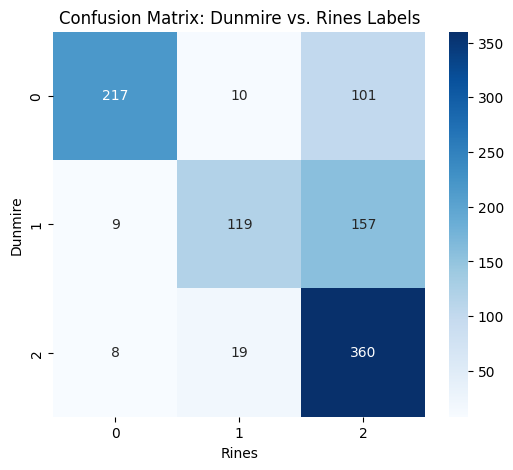

In [4]:
## ========================================================= ##
## VISUALIZE DIFFERENCES IN LABELS BETWEEN DUNMIRE AND RINES ##
## ========================================================= ##


import pandas as pd


# 2) Pull out the numpy arrays
dun = ds_final.label_Dunmire.values
rin = ds_final.label_Rines.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['Dunmire'],
    colnames=['Rines'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Dunmire vs. Rines Labels")
plt.show()



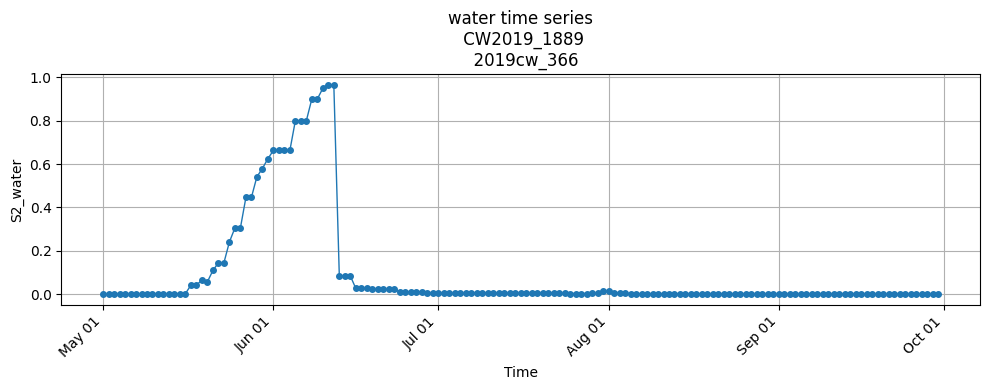

In [5]:
## ========================= ##
## PLOT AREA CURVE TO VERIFY ##
## ========================= ##

idx_lake = 365
times = ds_final.time.values
values = ds_final.S2_water[idx_lake].values

# drop NaNs
mask = ~np.isnan(values)
times = times[mask]
values = values[mask]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, 'o-', linewidth=1, markersize=4)

# set the major ticks to the 1st of each month
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))

# format those ticks however you like; here: “Jan 01” 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# rotate for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("S2_water")
ax.set_title(f"water time series\n {ds_final.ids[idx_lake].values}\n  2019cw_{idx_lake+1}")
ax.grid(True)
plt.tight_layout()
plt.show()



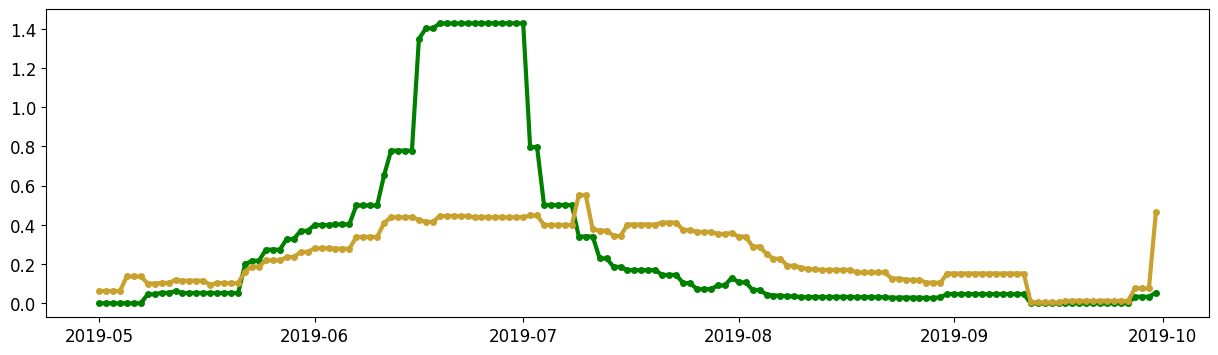

In [3]:


plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x/y labels
    'xtick.labelsize': 12,   # x‐tick labels
    'ytick.labelsize': 12,   # y‐tick labels
    'legend.fontsize': 12,   # legend text
    'legend.title_fontsize': 14
})

# lakes and their mustard‐adjusted colors
lake_ids = [825, 820]
colors = {
    825: 'green',
    820: '#C9A12F',    # mustard yellow
}

# one label per lake (in the same order as lake_ids)
laketype = [
    "hydrofracture", "lateral flow"
]

fig, ax = plt.subplots(figsize=(15, 4))

area_km_826 = []
area_km_820 = []
for idx_lake, lid in enumerate(lake_ids):
    vals = ds_final.S2_water[lid].values
    mask = ~np.isnan(vals)
    t = ds_final.time.values[mask]
    v = vals[mask]
    if lid==825:
        n_water_pix = 1.5e4 * v
        area = n_water_pix * 100
        area_km = area/1e6
        area_km_826.append(area_km)
        ax.plot(t, area_km, 'o-', 
                color=colors[lid],
                linewidth=3, 
                markersize=4,
                label=laketype[idx_lake])
    elif lid==820:
        n_water_pix = 0.75e4 * v
        area = n_water_pix * 100
        area_km = area/1e6
        area_km_820.append(area_km)
        ax.plot(t, area_km, 'o-', 
                color=colors[lid],
                linewidth=3, 
                markersize=4,
                label=laketype[idx_lake])

# ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# ax.set_xlabel("Time")
# ax.set_ylabel("% Water")
# ax.set_title("Lake Evolution Time Series")
# ax.grid(True)

# # place legend outside upper right
# ax.legend(
#     title="Drainage Type",
#     loc='upper left',              # anchor the legend’s upper-left corner...
#     bbox_to_anchor=(1.02, 1),      # … at x=1.02 (just outside), y=1 (top of axes)
#     borderaxespad=0                # no padding between axes and legend
# )


# fig, ax = plt.subplots(figsize=(15, 4))

# # --- plot each lake with positional indexing (.isel) ---
# for lid in lake_ids:
#     vals = ds_final.S2_water.isel(ids=lid).values
#     mask = ~np.isnan(vals)
#     t = ds_final.time.values[mask]
#     v = vals[mask]
#     v_plot = 1.5e4 * v / 1.5e6
#     ax.plot(t, v_plot, 'o-',
#             color=colors[lid],
#             linewidth=3,
#             markersize=4,
#             label=laketype[lake_ids.index(lid)])

# # --- compute & plot sum of both lakes ---
# sum_vals = ds_final.S2_water.isel(ids=lake_ids).sum(dim='ids').values
# mask_sum = ~np.isnan(sum_vals)
# t_sum    = ds_final.time.values[mask_sum]
# v_sum    = sum_vals[mask_sum]

# ax.plot(t_sum, v_sum, 'o-',
#         color='blue',
#         linewidth=3,
#         markersize=4,
#         label='sum of both')

# # --- formatting ---
# ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
# plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# ax.set_xlabel("Time")
# ax.set_ylabel("% Water")
# ax.set_title("Lake Evolution Time Series")
# ax.grid(True)

# ax.legend(
#     title="Series",
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0
# )

# fig.tight_layout()
# plt.show()


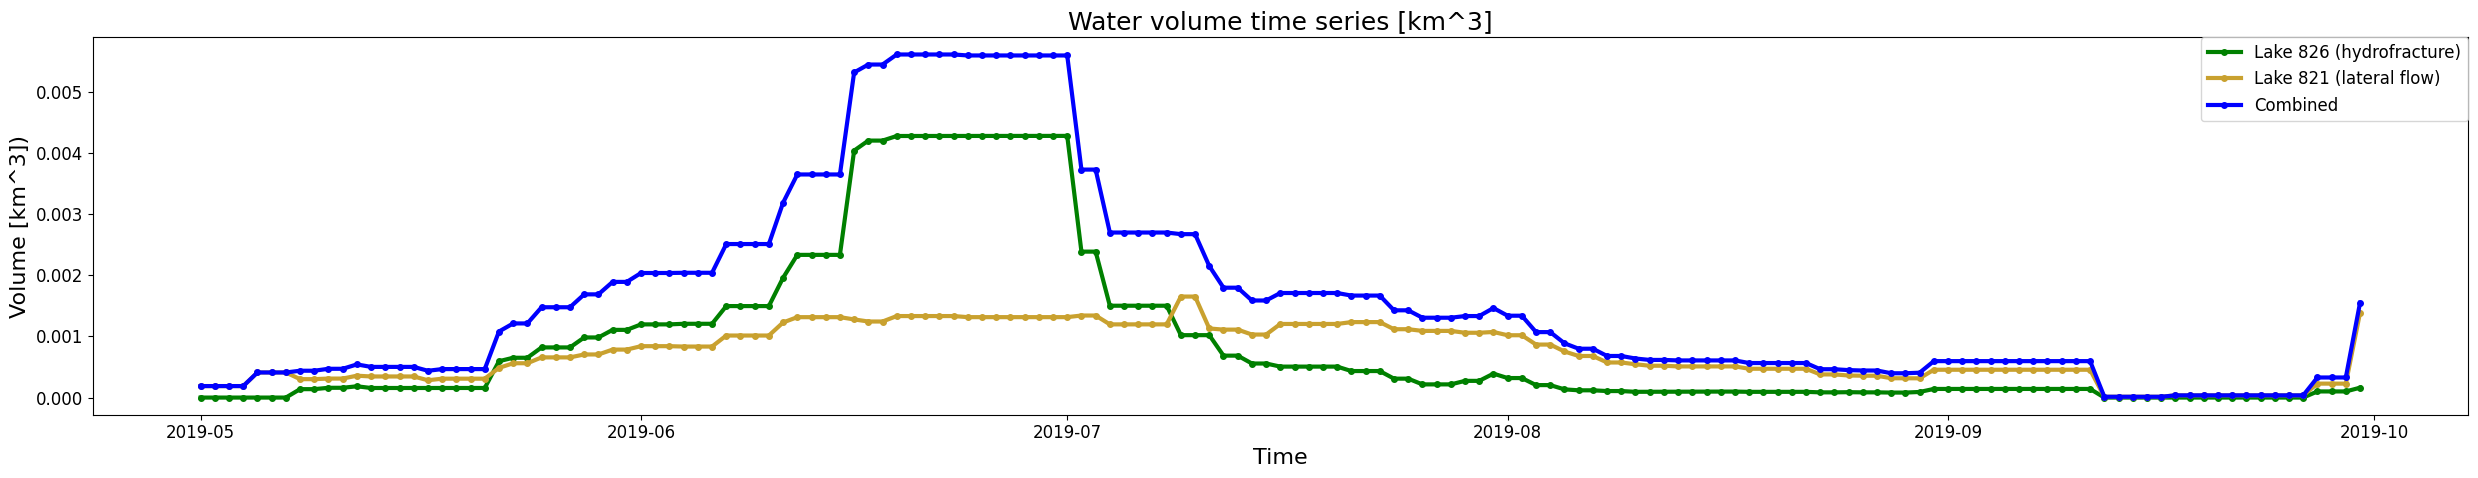

In [11]:
plt.figure(figsize=(25,5))

# 1st series: lake 826, hydrofracture
plt.plot(
    t, area_km_826[0]*3e-3,
    'o-',
    color=colors[825],
    linewidth=3,
    markersize=4,
    label='Lake 826 (hydrofracture)'
)

# 2nd series: lake 821, lateral flow
plt.plot(
    t, area_km_820[0]*3e-3,
    'o-',
    color=colors[820],
    linewidth=3,
    markersize=4,
    label='Lake 821 (lateral flow)'
)

# 3rd series: combined
plt.plot(
    t,
    (area_km_826[0] + area_km_820[0]) *3e-3,
    'o-',
    color='blue',
    linewidth=3,
    markersize=4,
    label='Combined'
)

plt.xlabel("Time")
plt.ylabel("Volume [km^3])")
plt.title("Water volume time series [km^3]")

# draw legend
plt.legend(borderaxespad=0)

plt.tight_layout()
plt.show()



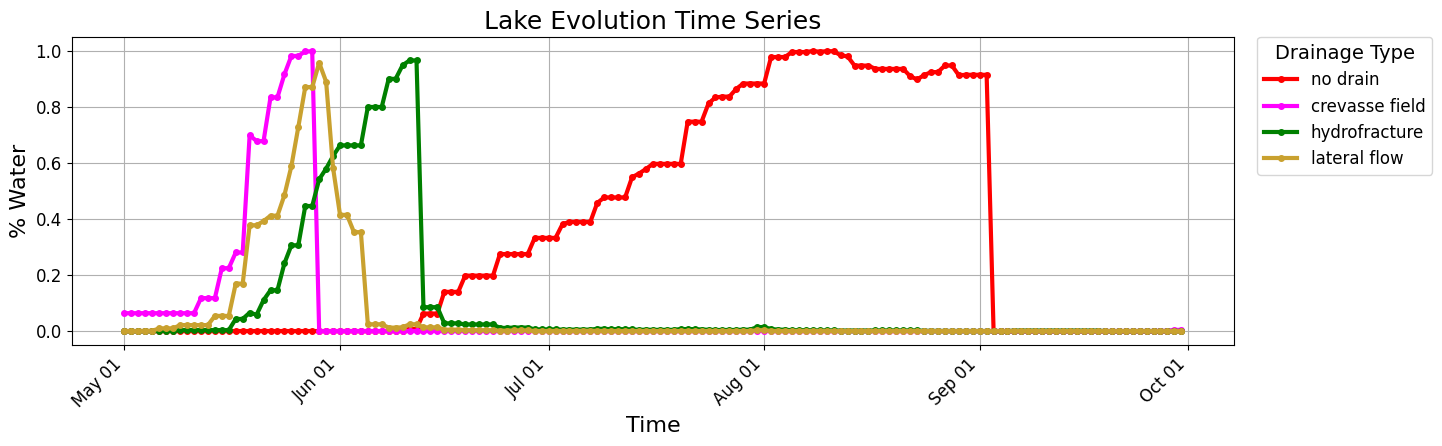

In [6]:


plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 18,    # title
    'axes.labelsize': 16,    # x/y labels
    'xtick.labelsize': 12,   # x‐tick labels
    'ytick.labelsize': 12,   # y‐tick labels
    'legend.fontsize': 12,   # legend text
    'legend.title_fontsize': 14
})

# lakes and their mustard‐adjusted colors
lake_ids = [40, 520, 365, 332]
colors = {
    40:  'red',
    520: 'magenta',
    365: 'green',
    332: '#C9A12F',    # mustard yellow
}

# one label per lake (in the same order as lake_ids)
laketype = [
    "no drain", 
    "crevasse field", 
    "hydrofracture", "lateral flow"
]

fig, ax = plt.subplots(figsize=(15, 4))

for idx_lake, lid in enumerate(lake_ids):
    vals = ds_final.S2_water[lid].values
    mask = ~np.isnan(vals)
    t = ds_final.time.values[mask]
    v = vals[mask]
    
    ax.plot(t, v, 'o-', 
            color=colors[lid],
            linewidth=3, 
            markersize=4,
            label=laketype[idx_lake])

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("% Water")
ax.set_title("Lake Evolution Time Series")
ax.grid(True)

# place legend outside upper right
ax.legend(
    title="Drainage Type",
    loc='upper left',              # anchor the legend’s upper-left corner...
    bbox_to_anchor=(1.02, 1),      # … at x=1.02 (just outside), y=1 (top of axes)
    borderaxespad=0                # no padding between axes and legend
)


In [7]:
## ==================== ##
## DEFINE DATASET CLASS ##
## ==================== ##

class DatasetTimeSequenceS2L8LA(Dataset):
    def __init__(self, fp_h5_images, ds_CW, seq_len=21, transform=None):
        self.fp_h5_images = fp_h5_images
        self.ds           = ds_CW
        self.seq_len      = seq_len
        self.transform    = transform

        self.area_seqs = ds_CW.S2_water.values               # (n_lakes, n_time)
        self.idx_max = ds_CW.S2_water.argmax(dim="time").values  # (n_lakes,)
        self.labels_Rines = ds_CW.label_Rines.values                 # (n_lakes,)
        self.labels_Dunmire = ds_CW.label_Dunmire.values                 # (n_lakes,)

    def __len__(self):
        return self.ds.sizes["ids"]

    def __getitem__(self, idx):
        # 1) identify lake
        lakenum = self.ds.lakenum.values[idx]  # e.g. "2019cw_366"

        # 2) load full image sequence
        with h5py.File(self.fp_h5_images, 'r') as f:
            img_seq = f[f'cw_2019_lakenum_{lakenum}'][()]  # (T, C, H, W)
            img_seq = img_seq[:,1:4,] # limit to just S2 bands

        # 3) slice window around max‐area time
        center = int(self.idx_max[idx])
        half   = self.seq_len // 2
        start  = max(0, center - half)
        end    = min(img_seq.shape[0], center + half + 1)

        if end - start < self.seq_len:
            if start == 0:
                end = min(self.seq_len, img_seq.shape[0])
            else:
                start = max(0, img_seq.shape[0] - self.seq_len)

        img_seq = img_seq[start:end]                    # (seq_len, C, H, W)
        area    = self.area_seqs[idx, start:end]        # (seq_len,)

        # 4) pull label
        label_Rines = int(self.labels_Rines[idx])
        label_Dunmire = int(self.labels_Dunmire[idx])

        # 5) to torch tensors
        img_seq = torch.tensor(img_seq, dtype=torch.float32)
        area    = torch.tensor(area,   dtype=torch.float32).unsqueeze(-1)
        label_Rines   = torch.tensor(label_Rines,  dtype=torch.long)
        label_Dunmire   = torch.tensor(label_Dunmire,  dtype=torch.long)

        # 6) optional transform
        if self.transform:
            img_seq = self.transform(img_seq)

        return img_seq, area, label_Rines, label_Dunmire, lakenum
    
    

In [6]:
## ======================== ##
## EXAMPLE BATCH GENERATION ##
## ======================== ##

fp_h5_images = "/home/jupyter/scratch/joshua/lakesproj/hdf5_files_scratch/cw_2019.hdf5"

# ds_CW must already exist from your previous steps
test_ds   = DatasetTimeSequenceS2L8LA(fp_h5_images, ds_final, seq_len=41)
test_loader = DataLoader(test_ds, batch_size=30, shuffle=True)

# grab one batch
img_batch, area_batch, label_batch_Rines, label_batch_Dunmire, lakenum_batch = next(iter(test_loader))

print(img_batch.shape)     # e.g. (4, 21, C, H, W)
print(area_batch.shape)    # (4, 21, 1)
print(label_batch_Rines)         # tensor([...])
print(label_batch_Dunmire)         # tensor([...])
print(lakenum_batch)       # list of 4 strings



torch.Size([30, 41, 3, 256, 256])
torch.Size([30, 41, 1])
tensor([2, 1, 2, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 2, 1, 1,
        2, 2, 0, 0, 1, 2])
tensor([2, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 1, 1, 1, 1,
        0, 2, 0, 0, 1, 2])
('2019cw_550', '2019cw_287', '2019cw_901', '2019cw_310', '2019cw_886', '2019cw_218', '2019cw_601', '2019cw_575', '2019cw_666', '2019cw_128', '2019cw_170', '2019cw_844', '2019cw_324', '2019cw_230', '2019cw_318', '2019cw_146', '2019cw_123', '2019cw_980', '2019cw_647', '2019cw_299', '2019cw_925', '2019cw_135', '2019cw_657', '2019cw_770', '2019cw_581', '2019cw_964', '2019cw_120', '2019cw_416', '2019cw_361', '2019cw_165')


In [8]:
## =============================================== ##
## INSTANTIATE TWO DATASET OBJECTS (TRAIN AND VAL) ##
## =============================================== ##

fp_h5_images = "/home/jupyter/scratch/joshua/lakesproj/hdf5_files_scratch/cw_2019.hdf5"


full_dataset = DatasetTimeSequenceS2L8LA(
    fp_h5_images=fp_h5_images,
    ds_CW=ds_final,
    seq_len=21,
    transform=None
)
train_dataset = DatasetTimeSequenceS2L8LA(
    fp_h5_images=fp_h5_images,
    ds_CW=ds_train,
    seq_len=21,
    transform=None
)
val_dataset = DatasetTimeSequenceS2L8LA(
    fp_h5_images=fp_h5_images,
    ds_CW=ds_val,
    seq_len=21,
    transform=None  # often you skip heavy augment on val
)



In [9]:
## ====================================== ##
## CREATE TWO DATALOADERS (TRAIN AND VAL) ##
## ====================================== ##

dl_train = DataLoader(
    train_dataset,
    batch_size=50,
    shuffle=True,
    num_workers=4,
    pin_memory=False
)
dl_val = DataLoader(
    val_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)



In [56]:
img_batch, area_batch, label_batch_Rines, label_batch_Dunmire, lakenum_batch = next(iter(dl_train))

img_batch.shape



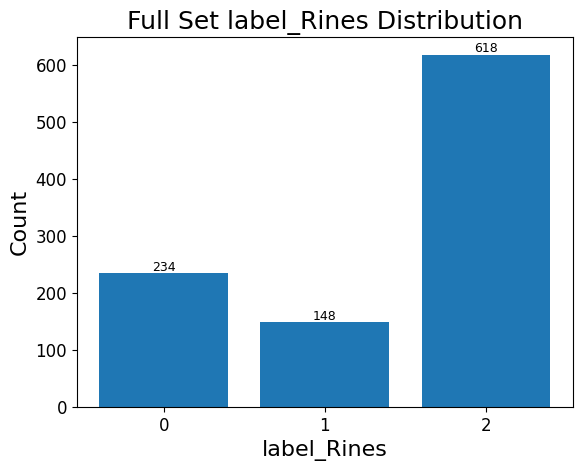

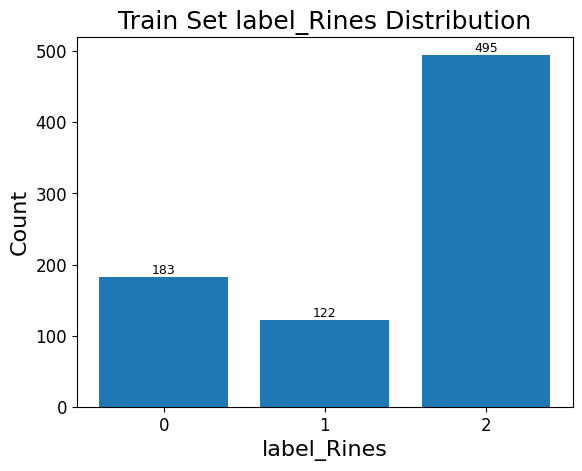

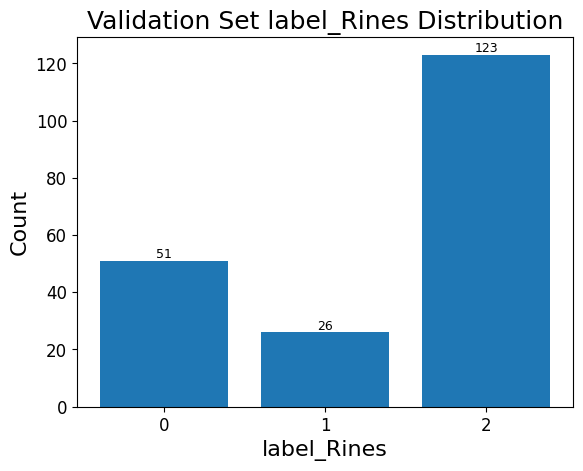

In [10]:
## =============================================================== ##
## PLOT DISTRIBUTIONS OF LABELS IN EACH DATASET (FULL, TRAIN, VAL) ##
## =============================================================== ##

# Extract labels
labels_full  = full_dataset.labels_Rines
labels_train = train_dataset.labels_Rines
labels_val   = val_dataset.labels_Rines

# Determine bins
classes = np.unique(np.concatenate([labels_train, labels_val]))
bins = np.arange(classes.min(), classes.max() + 2) - 0.5

def plot_with_counts(data, title):
    fig, ax = plt.subplots()
    counts, edges, patches = ax.hist(data, bins=bins, rwidth=0.8)
    ax.set_xticks(classes)
    ax.set_xlabel('label_Rines')
    ax.set_ylabel('Count')
    ax.set_title(title)

    # annotate each bar
    for count, patch in zip(counts, patches):
        if count > 0:
            x = patch.get_x() + patch.get_width() / 2
            y = count
            ax.text(x, y, str(int(count)), 
                    ha='center', va='bottom', fontsize=9)

    plt.show()

# Plot all three
plot_with_counts(labels_full,  'Full Set label_Rines Distribution')
plot_with_counts(labels_train, 'Train Set label_Rines Distribution')
plot_with_counts(labels_val,   'Validation Set label_Rines Distribution')


Lake 2019cw_979 — sequence length 21, channels 3, size 256×256


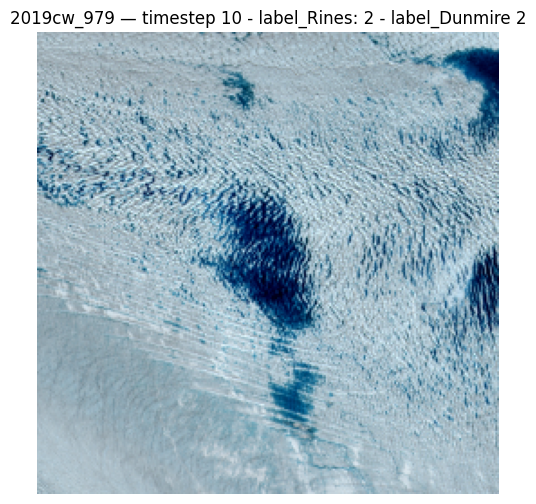

In [14]:
## ====================================== ##
## VISUALIZE ONE EXAMPLE FROM THE DATASET ##
## ====================================== ##

# 1) pull one example from the dataset
#    you can also do: batch = next(iter(train_loader)); img_seq, area, … = batch
img_seq, area, label_Rines, label_Dunmire, lakenum = train_dataset[0]

# img_seq is a tensor of shape (seq_len, C, H, W)
seq_len, C, H, W = img_seq.shape
print(f"Lake {lakenum} — sequence length {seq_len}, channels {C}, size {H}×{W}")

# 2) pick a time index to visualize
t = seq_len // 2  # middle of the sequence

# 3) select that frame, convert to H×W×C numpy
frame = img_seq[t]                 # (C, H, W)
frame_np = frame.permute(1, 2, 0).numpy()  # (H, W, C)

# 4) if your first 3 channels are R, G, B you can display an RGB:
plt.figure(figsize=(6,6))
plt.imshow(frame_np[..., :3])  # drop extra channels if >3
plt.title(f"{lakenum} — timestep {t} - label_Rines: {label_Rines} - label_Dunmire {label_Dunmire}")
plt.axis("off")
plt.show()



In [11]:
## DEFINE THE MODEL FOR USING IMAGERY, LAKEAREA MASKS, AND LAKEAREA SCALARS:
############################################################################

'''
this model has four parts:
    (1) CNN for feature extraction from each image in the sequence
        input: images in sequence (processed individually, not in sequence)
        output: feature vector for each time step
    (2a) LSTM(a) for processing sequence of feature vectors from CNN
        input: sequence of feature vectors from CNN (one sequence of feature vectors for each lake basin time sequence)
        output: hidden state vector (at all timesteps so we can eventually do attention, but will use the last lstm output for classification for now)
    (2b) LSTM(b) for processing time sequence of lake areas
    (3) MLP for classification
        input: hidden state vector from lstm
        output: classification of lake drainage type (0:ND, 1:HF, 2:Other)
'''

# PART ONE: CNN FEATURE EXTRACTOR
class FeatureExtractorCNN(nn.Module):
    def __init__(self, input_channels, use_dropout=False, dropout_prob=0.5):
        super(FeatureExtractorCNN, self).__init__()
        self.use_dropout = use_dropout
        self.conv_layers = nn.Sequential(
            # first block:
            nn.Conv2d(input_channels, 4, kernel_size=3, padding=1), # CONVOLUTION: size goes from (batch_size, input_channels=3, 256, 256) --> (batch_size, 4, 256, 256)
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),               # POOLING: size goes from (batch_size, 4, 256, 256) --> (batch_size, 4, 128, 128)
            # second block:
            nn.Conv2d(4, 8, kernel_size=3, padding=1),           # CONVOLUTION: size goes from (batch_size, 4, 128, 128) --> (batch_size, 8, 128, 128)
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),               # POOLING: size goes from (batch_size, 8, 128, 128) --> (batch_size, 8, 64, 64)
            # third block:
            nn.Conv2d(8, 16, kernel_size=3, padding=1),          # CONVOLUTION: size goes from (batch_size, 8, 64, 64) --> (batch_size, 16, 64, 64)
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                # POOLING: size goes from (batch_size, 16, 64, 64) --> (batch_size, 16, 32, 32)
        )
        
        # fully connected layer
        self.fc = nn.Linear(16*32*32, 32) # connects flattened output of the CNN to 32 nodes
        
        # optional dropout
        if use_dropout:
            self.dropout = nn.Dropout(dropout_prob)
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flatten the output of the CNN feature extractions, flattened shape is (batch_size, 32*64*64)
        x = self.fc(x) # pass the flattened output through the fully connected layer, which has 32 nodes, which is the length of the input vector for the LSTM
        if self.use_dropout:
            x = self.dropout(x) # apply dropout
            
        return x

# PART 2A: LSTM FOR IMAGE SEQUENCE
class SequenceProcessorLSTM(nn.Module):
    def __init__(self, input_size=32, hidden_size=32, num_layers=1, output_size=32, use_dropout=False, dropout_prob=0.5):
        super(SequenceProcessorLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_dropout = use_dropout
        
        # define the lstm:
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # define output linear layer to get the output to the right output_size:
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        if use_dropout:
            self.dropout = nn.Dropout(dropout_prob)
        
    def forward(self, x):
        # initialize hidden and cell states:
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # forward pass propagate LSTM:
        lstm_out, _ = self.lstm(x, (h0,c0))
        if self.use_dropout:
            lstm_out = self.dropout(lstm_out)
        
        # pass through output_layer:
        out = self.output_layer(lstm_out)
        # returns:
        return out

# PART 2B: LSTM FOR LAKEAREA (scalar) SEQUENCE
class AreaSequenceProcessorLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, output_size=16, use_dropout=False, dropout_prob=0.5):
        super(AreaSequenceProcessorLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.use_dropout = use_dropout
        
        # Define LSTM for scalar sequences
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Define output linear layer to match desired output_size
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        if use_dropout:
            self.dropout = nn.Dropout(dropout_prob)
        
    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward pass through LSTM
        lstm_out, _ = self.lstm(x, (h0, c0))
        if self.use_dropout:
            lstm_out = self.dropout(lstm_out)
        
        # Pass through output layer
        out = self.output_layer(lstm_out)
        
        return out
    
# PART 3: MLP HEAD FOR CLASSIFICATION
class HeadMLP(nn.Module):
    def __init__(self, input_size=32, hidden_nodenums=[32,32], output_size=3, use_dropout=False, dropout_prob=0.5):
        super(HeadMLP, self).__init__()
        layers = []
        current_size = input_size
        
        # add hidden layers to MLP structure:
        for num_nodes in hidden_nodenums:
            layers.append(nn.Linear(current_size, num_nodes))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(dropout_prob))
            current_size = num_nodes
        
        # output layer
        layers.append(nn.Linear(current_size, output_size))
        
        # define the whole mlp structure:
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.mlp(x)
    

# CONSTRUCT THE WHOLE MODEL:
# UPDATED MODEL WITH ADDITIONAL AREA LSTM BRANCH
class CNN_LSTM_MLP_with_AreaBranch(nn.Module):
    def __init__(self, use_dropout=False, dropout_prob=0.5):
        super(CNN_LSTM_MLP_with_AreaBranch, self).__init__()
        
        # CNN for image sequence processing
        self.cnn = FeatureExtractorCNN(input_channels=3, use_dropout=use_dropout, dropout_prob=dropout_prob)
        
        # LSTM for image feature sequences
        self.image_lstm = SequenceProcessorLSTM(input_size=32, hidden_size=32, num_layers=1, output_size=32, use_dropout=use_dropout, dropout_prob=dropout_prob)
        
        # LSTM for area sequences
        self.area_lstm = AreaSequenceProcessorLSTM(input_size=1, hidden_size=16, num_layers=1, output_size=16, use_dropout=use_dropout, dropout_prob=dropout_prob)
        
        # MLP for classification
        self.mlp = HeadMLP(input_size=48, hidden_nodenums=[32, 32], output_size=3, use_dropout=use_dropout, dropout_prob=dropout_prob)
        
    def forward(self, image_seq, area_seq):
        """
        Args:
            image_seq: Tensor of shape [batch_size, seq_len, C, H, W]
            area_seq: Tensor of shape [batch_size, seq_len, 1]
        """
        # Process image sequence with CNN + image LSTM
        batch_size, seq_len, C, H, W = image_seq.size()
        image_seq = image_seq.view(batch_size * seq_len, C, H, W)  # Flatten for CNN
        cnn_features = self.cnn(image_seq)  # Shape: [batch_size * seq_len, feature_dim]
        cnn_features = cnn_features.view(batch_size, seq_len, -1)  # Reshape for LSTM
        image_lstm_out = self.image_lstm(cnn_features)  # Shape: [batch_size, seq_len, hidden_size]
        image_lstm_last = image_lstm_out[:, -1, :]  # Use the last time step
        # Process area sequence with area LSTM
        area_lstm_out = self.area_lstm(area_seq)  # Shape: [batch_size, seq_len, hidden_size]
        area_lstm_last = area_lstm_out[:, -1, :]  # Use the last time step
        # Combine the outputs of both LSTMs
        combined_features = torch.cat([image_lstm_last, area_lstm_last], dim=-1)  # Shape: [batch_size, 48]
        # Uncomment the following line if you want to use addition instead of concatenation
        # combined_features = image_lstm_last + area_lstm_last  # Ensure the hidden sizes are the same if using addition
        
        # Pass the combined features through the MLP head
        output = self.mlp(combined_features)  # Shape: [batch_size, num_classes]
        
        return output
    
    

In [12]:
## INITIALIZE THE FULL MODEL ##
###############################

# model = CNN_LSTM_MLP(use_dropout=True, dropout_prob=0.63)
model = CNN_LSTM_MLP_with_AreaBranch(use_dropout=False, dropout_prob=0.0)



In [13]:
## SET DEVICE TO CUDA: ##
#########################

# Select default GPU
default_gpu = 0  # Change this to the desired GPU index
device = torch.device(f'cuda:{default_gpu}' if torch.cuda.is_available() else 'cpu')
# Use DataParallel to split across all available GPUs
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for training")
    model = nn.DataParallel(model, device_ids=[i for i in range(torch.cuda.device_count())])
# Move model to the appropriate device
model.to(device)



Using 2 GPUs for training


DataParallel(
  (module): CNN_LSTM_MLP_with_AreaBranch(
    (cnn): FeatureExtractorCNN(
      (conv_layers): Sequential(
        (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): LeakyReLU(negative_slope=0.01)
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): LeakyReLU(negative_slope=0.01)
        (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (6): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (7): LeakyReLU(negative_slope=0.01)
        (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (fc): Linear(in_features=16384, out_features=32, bias=True)
    )
    (image_lstm): SequenceProcessorLSTM(
      (lstm): LSTM(32, 32, batch_first=True)
      (output_layer): Linear(in_features=32, out_features=32, bias=True)
    )
    (a

In [ ]:
## FULL TRAINING LOOP: ##
#########################

# loss, and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # use this for l2 regularization
num_epochs = 100  # Set your desired number of epochs

# set whether or not the output and error messages should be sent to other files
redirect_output_to_files = False # redirect files to output and error logs (True/False)
if redirect_output_to_files:
    filepath_outputs = '/home/jupyter/lakes/AGU24/logs/augmented/LSTM_timeseq/file_outs_LSTMtimeseq.out'
    filepath_errors = '/home/jupyter/lakes/AGU24/logs/augmented/LSTM_timeseq/file_errs_LSTMtimeseq.err'
    print(f"outputs going to {filepath_outputs}")
    print(f"errors going to {filepath_errors}")
    # Open files for output and error
    sys.stdout = open(filepath_outputs, 'w')
    sys.stderr = open(filepath_errors, 'w')

try:
    print(f"TRAINING STARTED: {num_epochs} epochs planned \n")


    # initialize collection lists for preds, labels, losses, and probabilities
    preds_train, labels_train, losses_train, probs_train = [], [], [], []
    preds_val, labels_val, losses_val, probs_val = [], [], [], []

    # start the clock:
    t_start = time.time()

    # TRAINING LOOP:
    for epoch in range(num_epochs):
        print(f"epoch {epoch}")

        # TRAINING PHASE: 
        model.train()  # Set model to training mode
        running_loss_train = 0.0
        epoch_preds_train = []
        epoch_labels_train = []
        epoch_probs_train = []
        for img_seqs, area_seqs, labelsR, labelsD, lakenums in dl_train:
            # print(f"batch")
            # Move data to the device
            img_seqs = img_seqs.float().to(device)
            labels = labelsR.long().to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            logits = model(img_seqs, area_seqs)

            # Compute loss
            loss = criterion(logits, labels)

            # Backward pass and optimize
            loss.backward()
            
            # # Inspect gradients
            # for name, param in model.named_parameters():
            #     if param.grad is not None:
            #         grad_norm = param.grad.data.norm(2).item()
            #         print(f"Layer: {name} | Gradient Norm: {grad_norm:.6f}")
            #     else:
            #         print(f"Layer: {name} | Gradient is None")
                    
            # Optimize the model parameters
            optimizer.step()

            # Accumulate loss
            running_loss_train += loss.item()

            # Apply softmax to get probabilities for each class
            probs = torch.softmax(logits, dim=1)

            # Collect predictions, labels, and probabilities
            predicted_classes = torch.argmax(logits, dim=1)  # Get class indices with highest score
            epoch_preds_train.extend(predicted_classes.detach().cpu().numpy())
            epoch_labels_train.extend(labels.detach().cpu().numpy())
            epoch_probs_train.extend(probs.detach().cpu().numpy()) 

        # Calculate training accuracy
        epoch_preds_train = np.array(epoch_preds_train)
        epoch_labels_train = np.array(epoch_labels_train)
        train_accuracy = (epoch_preds_train == epoch_labels_train).mean()
        
        # Calculate metrics for training
        train_precision = precision_score(epoch_labels_train, epoch_preds_train, average='weighted', zero_division=0)
        train_recall = recall_score(epoch_labels_train, epoch_preds_train, average='weighted', zero_division=0)
        train_f1 = f1_score(epoch_labels_train, epoch_preds_train, average='weighted', zero_division=0)

        # At the end of each epoch, add epoch_preds, epoch_labels, and epoch_probs to the lists
        preds_train.append(epoch_preds_train)
        labels_train.append(epoch_labels_train)
        probs_train.append(epoch_probs_train)
        losses_train.append(running_loss_train / len(dl_train))

        # VALIDATION PHASE:
        model.eval()  # Set the model to evaluation mode
        running_loss_val = 0.0
        epoch_preds_val = []
        epoch_labels_val = []
        epoch_probs_val = []
        with torch.no_grad():
            for img_seqs, area_seqs, labelsR, labelsD, lakenums in dl_val:
                img_seqs = img_seqs.float().to(device)
                labels = labelsR.long().to(device)

                # forward pass
                logits = model(img_seqs, area_seqs)

                # compute and accumulate loss
                loss = criterion(logits, labels)
                running_loss_val += loss.item()

                # Apply softmax to get probabilities for each class
                probs = torch.softmax(logits, dim=1)

                # Collect predictions, labels, and probabilities
                predicted_classes = torch.argmax(logits, dim=1)  # Get class indices with highest score
                epoch_preds_val.extend(predicted_classes.detach().cpu().numpy())
                epoch_labels_val.extend(labels.detach().cpu().numpy())
                epoch_probs_val.extend(probs.detach().cpu().numpy())
                
                # Calculate distribution of predictions and labels using numpy
                unique_preds_train, pred_counts_train = np.unique(epoch_preds_train, return_counts=True)
                unique_labels_train, label_counts_train = np.unique(epoch_labels_train, return_counts=True)

        # Calculate validation accuracy
        epoch_preds_val = np.array(epoch_preds_val)
        epoch_labels_val = np.array(epoch_labels_val)
        val_accuracy = (epoch_preds_val == epoch_labels_val).mean()
        
        # Calculate metrics for validation
        val_precision = precision_score(epoch_labels_val, epoch_preds_val, average='weighted', zero_division=0)
        val_recall = recall_score(epoch_labels_val, epoch_preds_val, average='weighted', zero_division=0)
        val_f1 = f1_score(epoch_labels_val, epoch_preds_val, average='weighted', zero_division=0)
        
        # Calculate distribution of predictions and labels using numpy
        unique_preds_val, pred_counts_val = np.unique(epoch_preds_val, return_counts=True)
        unique_labels_val, label_counts_val = np.unique(epoch_labels_val, return_counts=True)

        # Append validation data to the lists
        preds_val.append(epoch_preds_val)
        labels_val.append(epoch_labels_val)
        probs_val.append(epoch_probs_val)
        losses_val.append(running_loss_val / len(dl_val))

        # clear memory after each epoch
        torch.cuda.empty_cache()  # Release cached memory
        gc.collect()  # Run garbage collection

        t_epoch = time.time() - t_start

        # Print after epoch
        print(
            f"Epoch [{epoch}/{num_epochs-1}]; Elapsed: {t_epoch/60:.3f} min\n"
            f"\tLOSS: Train: {running_loss_train/len(dl_train):.4f}; Val: {running_loss_val/len(dl_val):.4f} //\n"
            f"\tACC:  Train: {train_accuracy:.4f}; Val: {val_accuracy:.4f} //\n"
            f"\tPREC: Train: {train_precision:.4f}; Val: {val_precision:.4f} //\n"
            f"\tREC:  Train: {train_recall:.4f}; Val: {val_recall:.4f} //\n"
            f"\tF1:   Train: {train_f1:.4f}; Val: {val_f1:.4f} //\n"
            f"\tPredicted Counts Train: "
            f"{ {int(k): int(v) for k, v in zip(unique_preds_train, pred_counts_train)} }; "
            f"Label Counts Train: "
            f"{ {int(k): int(v) for k, v in zip(unique_labels_train, label_counts_train)} } //\n"
            f"\tPredicted Counts Val:   "
            f"{ {int(k): int(v) for k, v in zip(unique_preds_val, pred_counts_val)} }; "
            f"Label Counts Val:   "
            f"{ {int(k): int(v) for k, v in zip(unique_labels_val, label_counts_val)} }"
        )
    
        # Save model weights every 10 epochs
        if (epoch) % 10 == 0 or (epoch)==num_epochs-1:
            torch.save(model.state_dict(), f"/home/jupyter/repos/lake-vision/sandbox/weights/lstm_drainTYPE_{epoch}.pth")

            # Save losses, predictions, and labels
            np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/losses_train_epoch_{epoch}.npy", losses_train)
            np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/losses_val_epoch_{epoch}.npy", losses_val)
            np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/preds_train_epoch_{epoch}.npy", preds_train)
            np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/preds_val_epoch_{epoch}.npy", preds_val)
            np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/labels_train_epoch_{epoch}.npy", labels_train)
            np.save(f"/home/jupyter/repos/lake-vision/sandbox/logs/labels_val_epoch_{epoch}.npy", labels_val)
    
except Exception as e:
    print(f"An error occurred: {e}", file=sys.stderr)  # Will go to 'error.log' or terminal
print("TRAINING COMPLETE.")    
    
    

TRAINING STARTED: 100 epochs planned 

epoch 0
Epoch [0/99]; Elapsed: 6.431 min
	LOSS: Train: 0.9157; Val: 0.9026 //
	ACC:  Train: 0.6188; Val: 0.6150 //
	PREC: Train: 0.3829; Val: 0.3782 //
	REC:  Train: 0.6188; Val: 0.6150 //
	F1:   Train: 0.4730; Val: 0.4684 //
	Predicted Counts Train: {2: 800}; Label Counts Train: {0: 183, 1: 122, 2: 495} //
	Predicted Counts Val:   {2: 200}; Label Counts Val:   {0: 51, 1: 26, 2: 123}
epoch 1
Epoch [1/99]; Elapsed: 13.170 min
	LOSS: Train: 0.8966; Val: 0.8819 //
	ACC:  Train: 0.6188; Val: 0.6150 //
	PREC: Train: 0.3829; Val: 0.3782 //
	REC:  Train: 0.6188; Val: 0.6150 //
	F1:   Train: 0.4730; Val: 0.4684 //
	Predicted Counts Train: {2: 800}; Label Counts Train: {0: 183, 1: 122, 2: 495} //
	Predicted Counts Val:   {2: 200}; Label Counts Val:   {0: 51, 1: 26, 2: 123}
epoch 2
Epoch [2/99]; Elapsed: 19.819 min
	LOSS: Train: 0.8715; Val: 0.8570 //
	ACC:  Train: 0.6188; Val: 0.6150 //
	PREC: Train: 0.3829; Val: 0.3782 //
	REC:  Train: 0.6188; Val: 0.6150

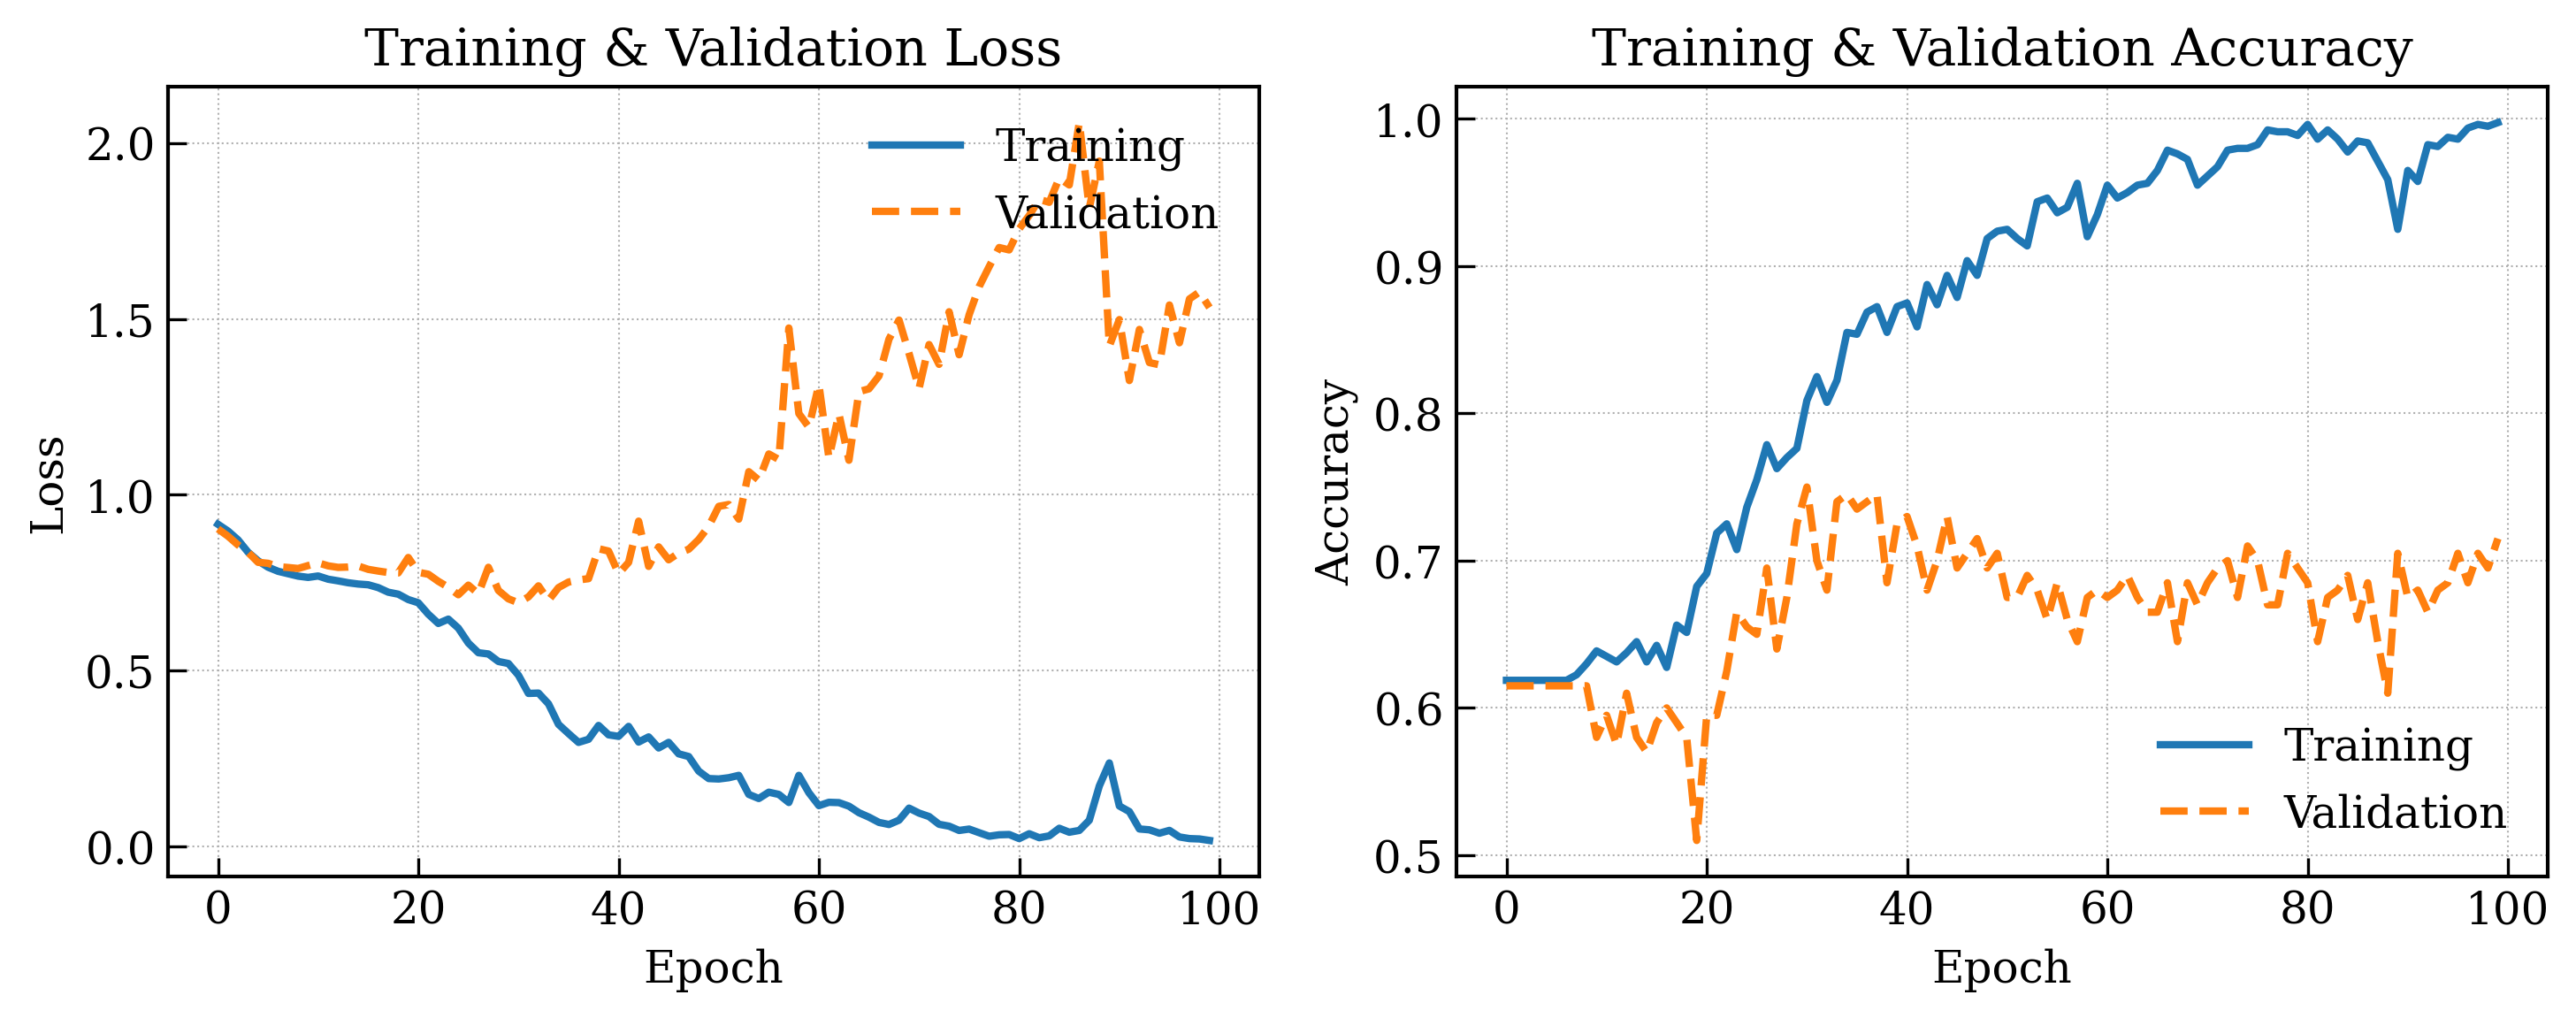

In [16]:
## VISUALIZE TRAINING OUTCOMES (e.g., loss, accuracy, etc.) ##
##############################


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Load your data
losses_train = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/losses_train_epoch_99.npy')
losses_val   = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/losses_val_epoch_99.npy')
preds_train  = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/preds_train_epoch_99.npy')
labels_train = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/labels_train_epoch_99.npy')
preds_val    = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/preds_val_epoch_99.npy')
labels_val   = np.load('/home/jupyter/repos/lake-vision/sandbox/logs/labels_val_epoch_99.npy')

# 2. Compute accuracies per epoch
accuracy_train = np.array([accuracy_score(labels_train[i], preds_train[i])
                           for i in range(len(preds_train))])
accuracy_val   = np.array([accuracy_score(labels_val[i],   preds_val[i])
                           for i in range(len(preds_val))])

# 3. Global styling
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.linewidth': 1.0,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'legend.frameon': False,
    'figure.dpi': 300
})

# 4. Create figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: Loss vs. Epoch ---
ax1.plot(losses_train, label='Training', linewidth=2)
ax1.plot(losses_val,   label='Validation', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.grid(True, linestyle=':', linewidth=0.5)
ax1.legend(loc='upper right')

# --- Right: Accuracy vs. Epoch ---
ax2.plot(accuracy_train, label='Training', linewidth=2)
ax2.plot(accuracy_val,   label='Validation', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.grid(True, linestyle=':', linewidth=0.5)
ax2.legend(loc='lower right')

# 5. Final layout tweaks
fig.tight_layout()

# 6. Save as vector PDF and high-res PNG
fig.savefig('/home/jupyter/repos/lake-vision/sandbox/figure_losses_accuracy.pdf', format='pdf')
fig.savefig('/home/jupyter/repos/lake-vision/sandbox/figure_losses_accuracy.png', dpi=300, format='png')

plt.show()



In [17]:
## ================== ##
## LOAD TRAINED MODEL ##
## ================== ##

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Build your model and wrap it
model = CNN_LSTM_MLP_with_AreaBranch(use_dropout=False, dropout_prob=0.0)
model = nn.DataParallel(model)

missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
model.to(device).eval()

# 2) Load the checkpoint (keys already have 'module.')
state = torch.load("/home/jupyter/repos/lake-vision/sandbox/weights/lstm_drainTYPE_99.pth", map_location=device)
model.load_state_dict(state)

# 3) Move to device & eval
model.to(device).eval()



NameError: name 'state' is not defined

In [18]:
## ========================================================================= ##
## FOR A GIVEN MODEL STATE (WEIGHTS) GET PREDS FOR BOTH SETS (TRAIN AND VAL) ##
## ========================================================================= ##


def predict_with_loader(dl: DataLoader, model: torch.nn.Module, device="cuda"):
    """
    Run model on every item in dl (which must yield
    (img_seq, area_seq, _, _, lakenum) in the same order as ds.ids).
    Returns a numpy array of predicted classes in the same order.
    """
    model.to(device).eval()
    all_preds = []

    with torch.no_grad():
        for img_seq, area, _, _, _ in dl:
            # img_seq: (B, T, C, H, W), area: (B, T, 1)
            img_seq = img_seq.to(device)
            area    = area   .to(device)
            out = model(img_seq, area)           # → (B, num_classes)
            preds = out.argmax(dim=1).cpu().numpy()  # → (B,)
            all_preds.append(preds)

    return np.concatenate(all_preds, axis=0)  # (N_lakes,)

# — after loading your model —
# for inference we want loaders with shuffle=False:
dl_train_inf = DataLoader(
    train_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)
dl_val_inf = DataLoader(
    val_dataset,
    batch_size=50,
    shuffle=False,
    num_workers=4,
    pin_memory=False
)

train_preds = predict_with_loader(dl_train_inf, model, device=device)
val_preds   = predict_with_loader(dl_val_inf,   model, device=device)



In [38]:
# assign back into xarray (they line up because shuffle=False)
ds_train_wpreds = ds_train.assign(predicted_draintype=("ids", train_preds))
ds_val_wpreds   = ds_val  .assign(predicted_draintype=("ids", val_preds))

# sanity check
print(ds_train_wpreds.predicted_draintype.values.shape)  # → (n_train,)
print(ds_val_wpreds.  predicted_draintype.values.shape)  # → (n_val,)




(800,)
(200,)


In [41]:
ds_train_wpreds

<xarray.Dataset> Size: 9MB
Dimensions:              (ids: 800, time: 153)
Coordinates:
  * ids                  (ids) object 6kB 'CW2019_2502' ... 'CW2019_1618'
  * time                 (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    lakenum              (ids) object 6kB '2019cw_979' ... '2019cw_95'
Data variables: (12/15)
    S1_image_id          (ids, time) object 979kB '' ... 'S1A_IW_GRDH_1SDH_20...
    S1_code              (ids, time) object 979kB '' '25-A-1' ... '' '127-A-3'
    HV_lake              (ids, time) float64 979kB -19.39 -19.39 ... -8.004
    HV_out               (ids, time) float64 979kB -21.23 -21.23 ... -9.469
    S2_water             (ids, time) float64 979kB 0.00657 0.5967 ... 0.02659
    S2_zenith            (ids, time) float64 979kB 56.76 56.2 ... 70.57 70.57
    ...                   ...
    label_Dunmire_raw    (ids) int32 3kB 2 0 3 1 0 0 0 1 1 ... 2 2 3 2 2 1 2 2 1
    date_maxwater_S2     (ids) datetime64[ns] 6kB 2019-06-12 ... 2019-08-04
    date_maxwater_LS     (ids) datetime64[ns] 6kB 2019-07-25 ... 2019-08-04
    label_Rines          (ids) int64 6kB 2 0 0 2 0 2 0 1 2 ... 2 2 0 2 2 2 1 2 0
    label_Dunmire        (ids) int32 3kB 2 0 0 1 0 0 0 1 1 ... 2 2 0 2 2 1 2 2 1
    predicted_draintype  (ids) int64 6kB 2 0 0 2 0 2 0 1 2 ... 2 2 0 2 2 2 1 2 0

labels_Rines    0    1    2
preds                      
0             183    0    1
1               0  122    0
2               0    0  494


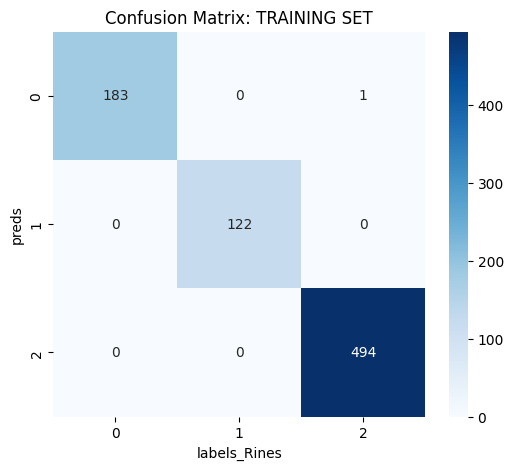

In [44]:

# 2) Pull out the numpy arrays
dun = ds_train_wpreds.predicted_draintype.values
rin = ds_train_wpreds.label_Rines.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Rines'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: TRAINING SET")
plt.show()


labels_Dunmire    0    1    2
preds                        
0               171    8    5
1                 8   97   17
2                79  123  292


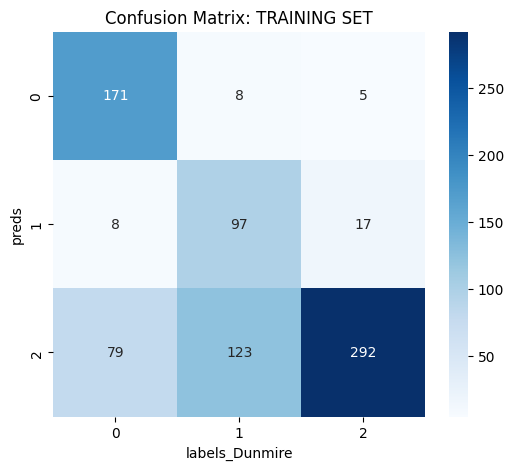

In [48]:

# 2) Pull out the numpy arrays
dun = ds_train_wpreds.predicted_draintype.values
rin = ds_train_wpreds.label_Dunmire.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Dunmire'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: TRAINING SET")
plt.show()



labels_Rines   0   1   2
preds                   
0             33   1  17
1              0  14  10
2             18  11  96


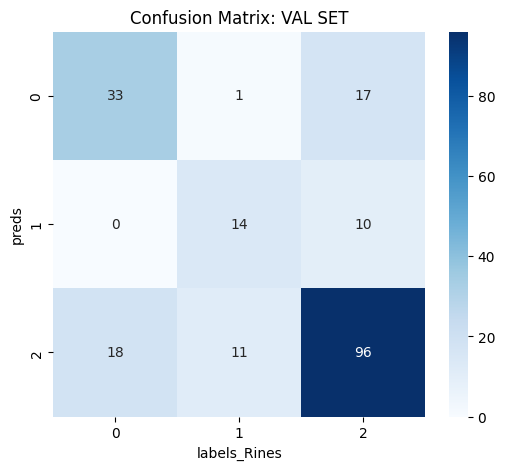

In [45]:

# 2) Pull out the numpy arrays
dun = ds_val_wpreds.predicted_draintype.values
rin = ds_val_wpreds.label_Rines.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Rines'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: VAL SET")
plt.show()


labels_Dunmire   0   1   2
preds                     
0               37   2  12
1                1  20   3
2               32  35  58


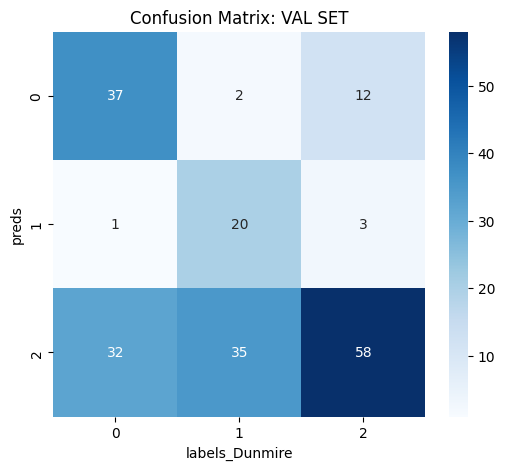

In [47]:

# 2) Pull out the numpy arrays
dun = ds_val_wpreds.predicted_draintype.values
rin = ds_val_wpreds.label_Dunmire.values

# 3) Build the confusion matrix
cm = pd.crosstab(
    dun,
    rin,
    rownames=['preds'],
    colnames=['labels_Dunmire'],
    dropna=False
)

# 4) (Optional) Print or plot
print(cm)




plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: VAL SET")
plt.show()


In [50]:
# 1) Flatten your xarray into a DataFrame
df = pd.DataFrame({
    'lakenum':           ds_val_wpreds.lakenum.values,
    'label_Dunmire':     ds_val_wpreds.label_Dunmire.values,
    'label_Rines':       ds_val_wpreds.label_Rines.values,
    'predicted_Rines':   ds_val_wpreds.predicted_draintype.values
})

# 2) Case 1: Dunmire=1 but model predicts 2 (and Rines=2)
mask1 = (
    (df['label_Dunmire']   == 1) &
    (df['label_Rines']     == 2) &
    (df['predicted_Rines'] == 2)
)
df_case1 = df[mask1]

# 3) Case 2: Dunmire=2 but model predicts 1 (and Rines=1)
mask2 = (
    (df['label_Dunmire']   == 2) &
    (df['label_Rines']     == 1) &
    (df['predicted_Rines'] == 1)
)
df_case2 = df[mask2]

# 4) Inspect
print(f"Case 1 (Dun=1 → Pred=2): {len(df_case1)} lakes")
display(df_case1)

print(f"Case 2 (Dun=2 → Pred=1): {len(df_case2)} lakes")
display(df_case2)


Case 1 (Dun=1 → Pred=2): 25 lakes


,lakenum,label_Dunmire,label_Rines,predicted_Rines
0,2019cw_561,1,2,2
11,2019cw_33,1,2,2
28,2019cw_371,1,2,2
30,2019cw_451,1,2,2
39,2019cw_397,1,2,2
44,2019cw_106,1,2,2
59,2019cw_484,1,2,2
61,2019cw_598,1,2,2
64,2019cw_443,1,2,2
68,2019cw_333,1,2,2


Case 2 (Dun=2 → Pred=1): 2 lakes


,lakenum,label_Dunmire,label_Rines,predicted_Rines
35,2019cw_268,2,1,1
65,2019cw_894,2,1,1
